First 5 Records
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7229300521  20141013T000000  231300.0         2       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode

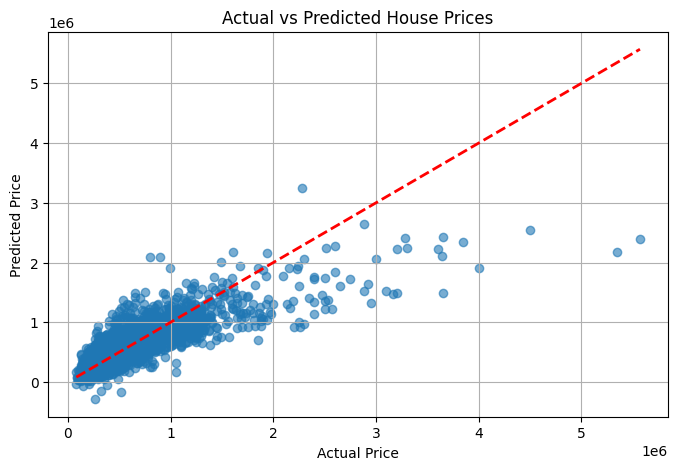

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==================================
# LOAD DATASET
# ==================================

df = pd.read_csv('/content/Housing.csv')

print('First 5 Records')
print(df.head())

print('\nColumns')
print(df.columns)

print('\nMissing Values')
print(df.isnull().sum())

# ==================================
# DATA CLEANING
# ==================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print('\nDataset Shape :', df.shape)

# ==================================
# SELECT IMPORTANT FEATURES
# ==================================

features = [
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement',
    'yr_built',
]

X = df[features]
y = df['price']

# ==================================
# SPLIT DATA
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==================================
# TRAIN MODEL
# ==================================

model = LinearRegression()
model.fit(X_train, y_train)

# ==================================
# PREDICT
# ==================================

y_pred = model.predict(X_test)

# ==================================
# VALIDATION
# ==================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('\nModel Validation (Multiple Linear Regression)')
print('-' * 45)
print(f'MAE  : ₹{mae:,.2f}')
print(f'RMSE : ₹{rmse:,.2f}')
print(f'R²   : {r2:.4f}')

# ==================================
# FEATURE IMPORTANCE
# ==================================

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print('\nTop Important Features')
print(importance)

# ==================================
# USER INPUT FOR HOUSE PRICE
# ==================================

sqft_living = float(input('\nEnter House Area (sq ft): '))
bedrooms = int(input('Enter Bedrooms: '))
bathrooms = float(input('Enter Bathrooms: '))
floors = float(input('Enter Floors: '))
waterfront = int(input('Waterfront? (0/1): '))
view = int(input('View Rating (0-4): '))
condition = int(input('Condition Rating (1-5): '))
grade = int(input('Grade (1-13): '))
sqft_above = float(input('Enter Sqft Above: '))
sqft_basement = float(input('Enter Sqft Basement: '))
yr_built = int(input('Enter Year Built: '))

# Create DataFrame with same feature order

user = pd.DataFrame([[
    sqft_living,
    bedrooms,
    bathrooms,
    floors,
    waterfront,
    view,
    condition,
    grade,
    sqft_above,
    sqft_basement,
    yr_built,
]], columns=features)

# ==================================
# PREDICT PRICE
# ==================================

predicted_price = model.predict(user)

print('\n' + '=' * 30)
print(f'Predicted House Price : ₹{predicted_price[0]:,.2f}')
print('=' * 30)

# ==================================
# ACTUAL vs PREDICTED GRAPH
# ==================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.grid(True)
plt.show()

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [11]:
r2 = r2_score(y_test, y_pred)

print("\nR2 Score :", round(r2, 4))


R2 Score : 0.6516
